# 01 — Preprocess one participant

Pipeline raw → processed pour 1 participant (mise au point/debug).
Pour faire tous les participants en lot, voir `02_batch_preprocess.ipynb`.

In [1]:
from resilience import paths, participants
from resilience.io import loader, writer
from resilience.processing import preprocess
from resilience.viz import plots
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
PARTICIPANT = '001CrMa'
CONDITION   = 'silence'

raw_path = paths.raw_file(PARTICIPANT, CONDITION)
data, fmt = loader.load_mat(raw_path)
trajectories = loader.extract_marker_trajectories(data, fmt)
loader.print_visibility_report(raw_path, trajectories)


════════════════════════════════════════════════════════════
  RAPPORT DIAGNOSTIQUE
  Fichier : 001CrMa_01_silence.mat
════════════════════════════════════════════════════════════
  Durée totale  : 480.0 s  (192000 frames @ 400 Hz)
  Après trim    : 420.0 s
  Marqueurs trouvés : 12/12

  Visibilité par marqueur (% frames non-NaN) :
    [dos]  médiane = 92.5%
         Dos01        → 91.4%
         Dos02        → 92.9%
         Dos03        → 93.3%
         Dos04        → 92.1%
    [pied_G]  médiane = 51.8%
      ⚠️ GLacet       → 39.1%
      ⚠️ GMT1         → 64.0%
      ⚠️ GMT5         → 39.6%
         GTalon       → 75.4%
    [pied_D]  médiane = 77.0%
      ⚠️ DLacet       → 45.2%
         DMT1         → 76.3%
         DMT5         → 77.7%
         DTalon       → 78.2%
════════════════════════════════════════════════════════════



   → compute_barycenter()
   → apply_emd_decomposition()
   EMD : 18 IMFs extraites, gardées [3, 4, 5, 6, 7, 8]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz


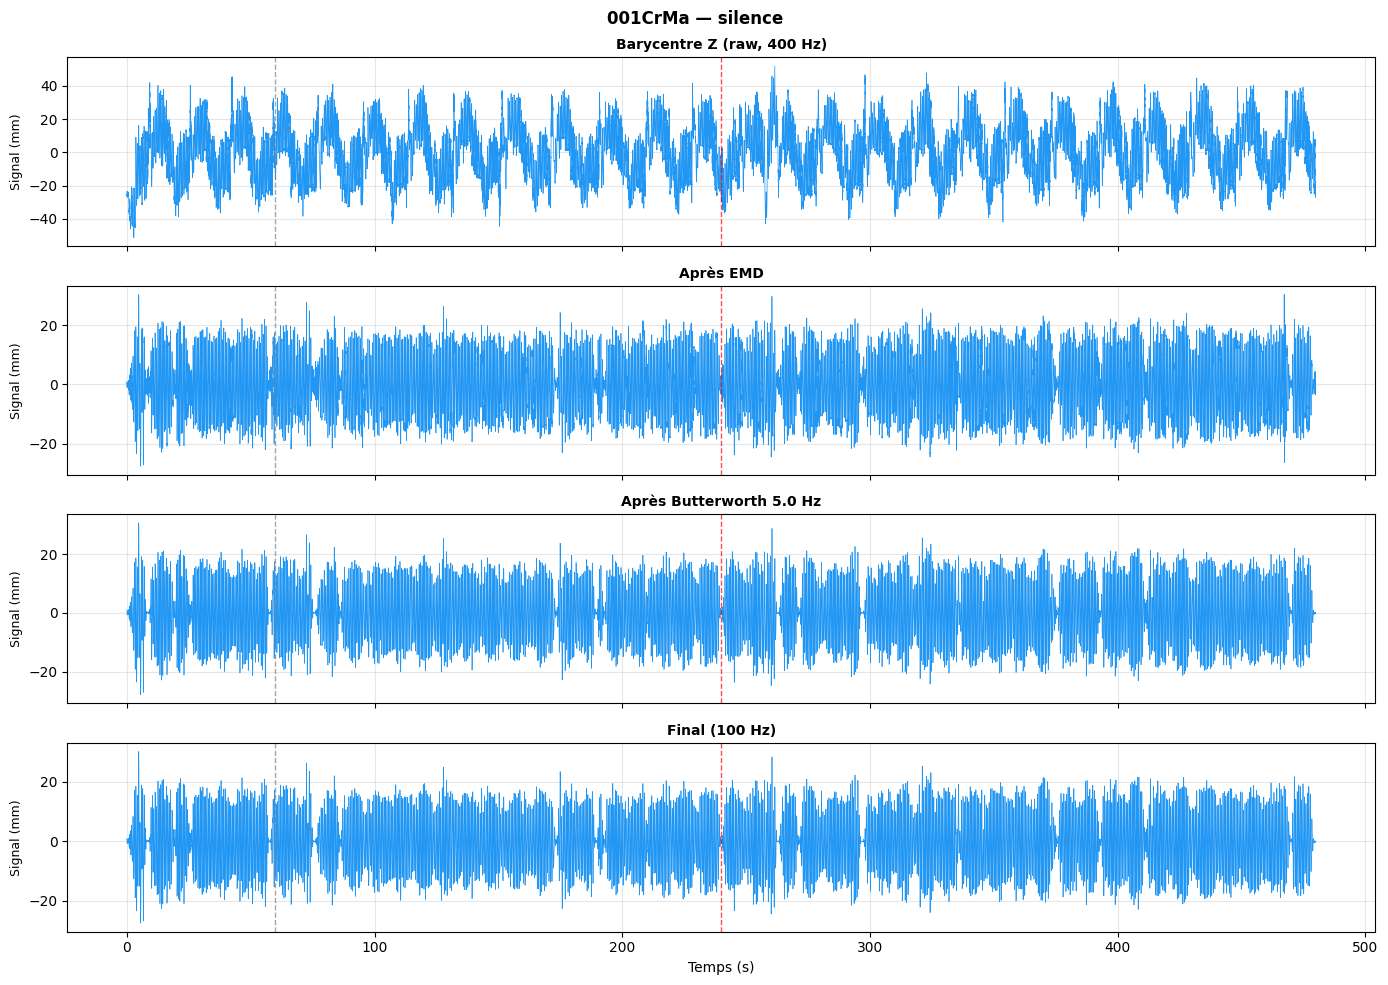

In [3]:
out = preprocess.run(trajectories)
fig = plots.plot_preprocessing_steps(out, title=f'{PARTICIPANT} — {CONDITION}')
plt.show()

In [4]:
npz_path = writer.save_processed(PARTICIPANT, CONDITION, out, trajectories_raw=trajectories)
print('Sauvegardé :', npz_path)

Sauvegardé : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\data\processed\001CrMa\001CrMa_01_silence.npz
